# Visualizing the True Impedance: The Smith Chart

Up to this point, we've looked at **Return Loss ($S_{11}$)** in decibels (dB), which tells us *how much* signal is reflected back. But in RF engineering, that's only half the story. We also need to know the *phase* of that reflection to understand how the device truly behaves.

Enter the **Smith Chart**.



### What is a Smith Chart? (The Non-Engineer's Guide)
Think of the Smith Chart as a dartboard or a GPS map for radio frequencies:
* **The Center (Bullseye):** This is perfect harmony (usually $50\ \Omega$). If our measurement lands here, it means 100% of the signal goes through and nothing bounces back. This is our ultimate goal!
* **The Outer Edge:** These are the "dead ends" (short circuits or open circuits). If we are on the edge, the signal hits a wall and bounces entirely back.
* **The Curves inside:** As we change the frequency (from 0 to 10 GHz), our measurement "moves" along these curved streets. The top half means the device acts like a coil (inductive), and the bottom half means it acts like a capacitor (capacitive).

### Why are we doing this? (The "Why")
When we measure our Device Under Test (DUT) with cables and fixtures attached, those extra cables add an electrical delay. On a Smith Chart, this delay looks like a **crazy, chaotic spiral** winding around the center. 

**Our goal with the De-embedding algorithm** is to mathematically "unwind" this spiral by subtracting the fixture's influence. 

In the plot below, we will draw three maps:
1. **Gray Line (Raw Measurement):** The chaotic spiral caused by the cables (`dut_plus_fixture`).
2. **Red Dashed Line (Golden Truth):** The true, ideal behavior of the device without noise or cables (`golden_dut`).
3. **Blue Line (Our Algorithm's Result):** The de-embedded data. If our math works, the blue line will completely unwind the gray spiral and perfectly overlap the red dashed line!

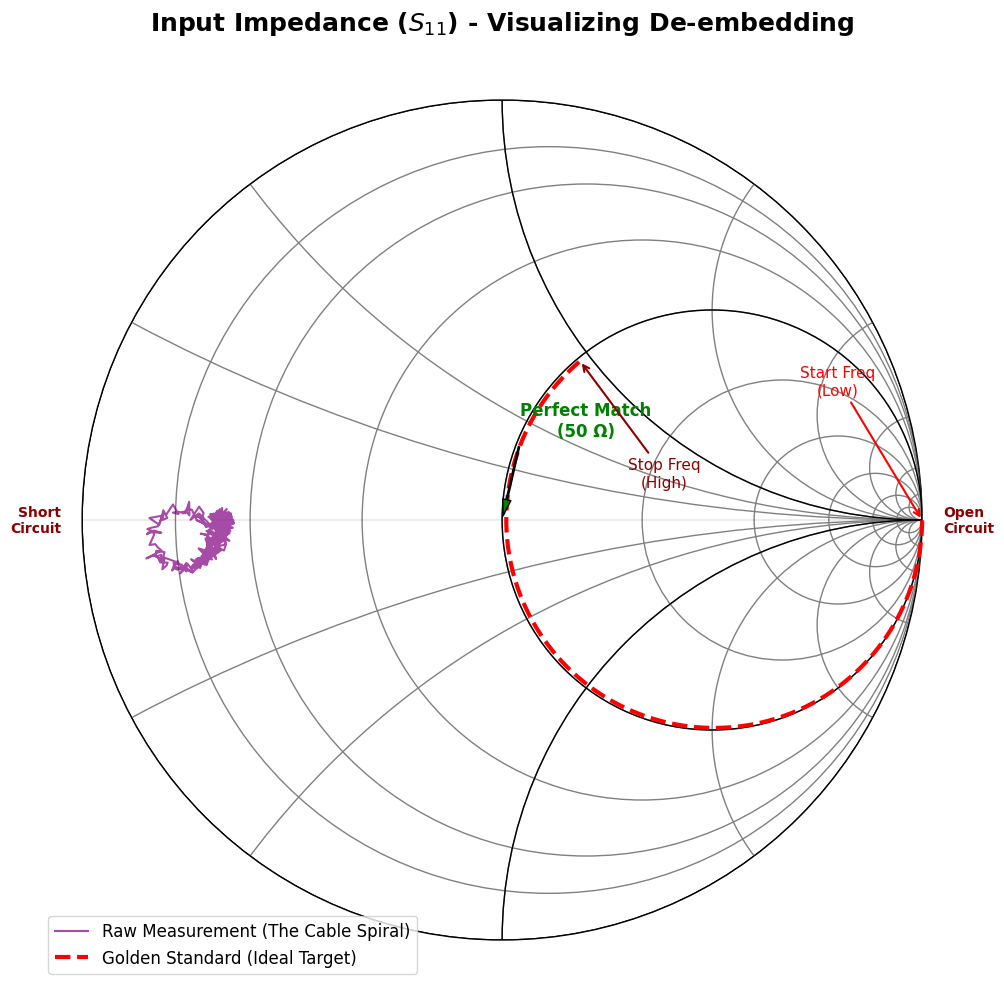

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import skrf as rf # Standard library for RF engineering in Python

# ---------------------------------------------------------
# Helper Function: Turn our CSVs into skrf Network objects
# ---------------------------------------------------------
def load_csv_to_rf_network(csv_file_path, network_name):
    """
    Reads our generated CSV files and constructs a complex S-parameter matrix.
    We need this because the Smith Chart requires both Real and Imaginary parts (Magnitude + Phase).
    """
    # 1. Read the data (using the updated column name 'frequency_Hz')
    df = pd.read_csv(csv_file_path)
    freqs = df['frequency_Hz'].values
    
    # 2. Create an empty container for the complex S-parameters (N_points, 2 ports, 2 ports)
    s_matrix = np.zeros((len(freqs), 2, 2), dtype=complex)
    
    # 3. Combine Real and Imaginary parts into complex numbers (Re + j*Im)
    s_matrix[:, 0, 0] = df['S11_real'] + 1j * df['S11_imag']
    s_matrix[:, 0, 1] = df['S12_real'] + 1j * df['S12_imag']
    s_matrix[:, 1, 0] = df['S21_real'] + 1j * df['S21_imag']
    s_matrix[:, 1, 1] = df['S22_real'] + 1j * df['S22_imag']
    
    # 4. Package it into a neat skrf Network object
    net = rf.Network(f=freqs, s=s_matrix, z0=50, name=network_name)
    net.frequency.unit = 'hz' # Tell skrf that our frequencies are in Hertz
    
    return net

# ---------------------------------------------------------
# 1. Load the Datasets
# ---------------------------------------------------------
net_raw = load_csv_to_rf_network("../measurement_data/dut_plus_fixture.csv", "Raw (DUT + Fixture)")
net_golden = load_csv_to_rf_network("../measurement_data/golden_dut.csv", "Golden (Ideal DUT)")

# NOTE: Uncomment when you generate the de-embedded CSV
# net_deembedded = load_csv_to_rf_network("../measurement_data/deembedded_dut.csv", "De-embedded (Our Algorithm)")

# ---------------------------------------------------------
# 2. Draw the Smith Chart with Explanatory Annotations
# ---------------------------------------------------------
plt.figure(figsize=(12, 12)) # Made it slightly larger for better readability

# Plot the Raw Measurement
net_raw.plot_s_smith(m=0, n=0, color='purple', linewidth=1.5, alpha=0.7,
                     label='Raw Measurement (The Cable Spiral)')

# Plot the Golden Truth
net_golden.plot_s_smith(m=0, n=0, color='red', linestyle='--', linewidth=3, 
                        label='Golden Standard (Ideal Target)')

# Plot the De-embedded Result
# net_deembedded.plot_s_smith(m=0, n=0, color='blue', linewidth=2.5, 
#                             label='De-embedded (Algorithm Proof)')

# --- ADDING EDUCATIONAL ANNOTATIONS TO MAKE IT CLEAR ---
ax = plt.gca()

# 1. Mark the Center (Perfect Match)
ax.annotate('Perfect Match\n(50 Ω)', xy=(0, 0), xytext=(0.2, 0.2),
            arrowprops=dict(facecolor='green', shrink=0.05, width=1, headwidth=6),
            fontsize=12, fontweight='bold', ha='center', color='green')

# 2. Mark Open and Short Circuits (The extremes)
ax.text(-1.05, 0, 'Short\nCircuit', color='darkred', ha='right', va='center', fontweight='bold')
ax.text(1.05, 0, 'Open\nCircuit', color='darkred', ha='left', va='center', fontweight='bold')

# 3. Mark the Start and Stop frequencies on the Golden curve to show direction
s11_golden = net_golden.s[:, 0, 0] # Extract the S11 complex values
start_x, start_y = s11_golden[0].real, s11_golden[0].imag
stop_x, stop_y = s11_golden[-1].real, s11_golden[-1].imag

ax.annotate('Start Freq\n(Low)', xy=(start_x, start_y), xytext=(start_x - 0.2, start_y + 0.3),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5), color='red', fontsize=11, ha='center')

ax.annotate('Stop Freq\n(High)', xy=(stop_x, stop_y), xytext=(stop_x + 0.2, stop_y - 0.3),
            arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5), color='darkred', fontsize=11, ha='center')
# -------------------------------------------------------

# Make it look pretty
plt.title("Input Impedance ($S_{11}$) - Visualizing De-embedding", fontsize=18, pad=20, fontweight='bold')
plt.legend(loc='lower left', fontsize=12) # Moved to lower left so it doesn't block the chart
plt.grid(False) 

# Show the masterpiece!
plt.show()